# ElectrAI / RHOAR-Net: End-to-End Training Demo

This notebook demonstrates a minimal training loop on the Materials Project sample data.
It serves as both documentation and a regression test (deterministic, reproducible results).

**Expected runtime:** ~2 minutes on CPU, ~30s on GPU

In [1]:
# Configuration
from __future__ import annotations

SEED = 42
EPOCHS = 5
EXPECTED_FINAL_VAL_LOSS = 0.639477  # Deterministic expected value
TOLERANCE = 0.001

## 1. Setup: Deterministic Environment

In [2]:
import os
from pathlib import Path

import torch
from lightning.pytorch import Callback, Trainer, seed_everything
from torch.utils.data import DataLoader

# Force deterministic behavior
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

seed_everything(SEED, workers=True)

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

print(f"Repo root: {repo_root}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Seed set to 42


Repo root: /Users/ryan/c/oa/electrai
PyTorch: 2.9.1
CUDA available: False


## 2. Configuration

We use a minimal model (8 channels, 2 residual blocks) for fast testing.
This is much smaller than production models (32-64 channels, 16-32 blocks).

In [3]:
class Config:
    """Minimal config for e2e testing."""

    # Dataset
    dataset_name = "mp"
    data_path = str(repo_root / "data/MP/chgcars/input")
    label_path = str(repo_root / "data/MP/chgcars/label")
    map_path = str(repo_root / "data/MP/map/map_sample.json.gz")
    rho_type = "chgcar"
    functional = "GGA"
    train_fraction = 0.6  # 3 train, 2 val from 5 samples
    num_workers = 0  # Single-threaded for determinism
    downsample_label = 1
    downsample_data = 0
    data_augmentation = False
    random_seed = SEED
    normalize = True
    data_precision = "f32"

    # Model (small for fast testing)
    n_channels = 8
    n_residual_blocks = 2
    n_upscale_layers = 0  # No upscaling (same resolution in/out)
    kernel_size1 = 3
    kernel_size2 = 3
    use_checkpoint = False

    # Training
    epochs = EPOCHS
    nbatch = 1
    lr = 0.001
    weight_decay = 0.0
    warmup_length = 1
    model_precision = 32
    gradient_clip_value = 1.0


cfg = Config()
print(f"Model: {cfg.n_channels} channels, {cfg.n_residual_blocks} residual blocks")
print(f"Training: {cfg.epochs} epochs, batch size {cfg.nbatch}, lr {cfg.lr}")

Model: 8 channels, 2 residual blocks
Training: 5 epochs, batch size 1, lr 0.001


## 3. Load Data

We use 5 CHGCAR samples from the Materials Project:
- 3 for training
- 2 for validation

In [4]:
from electrai.dataloader.collate import collate_fn
from electrai.dataloader.registry import get_data

train_data, test_data = get_data(cfg)
print(f"Train samples: {len(train_data)}")
print(f"Val samples: {len(test_data)}")

train_loader = DataLoader(
    train_data,
    batch_size=cfg.nbatch,
    shuffle=True,
    num_workers=cfg.num_workers,
    generator=torch.Generator().manual_seed(SEED),
)
test_loader = DataLoader(
    test_data,
    batch_size=cfg.nbatch,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=collate_fn,
)

Train samples: 3
Val samples: 2


## 4. Create Model

The model is a 3D ResNet adapted from SRGAN, with:
- Periodic boundary conditions (circular padding)
- InstanceNorm (works with batch size 1)
- PReLU activations
- Final normalization to preserve total electron count

In [5]:
from electrai.lightning import LightningGenerator

model = LightningGenerator(cfg)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 9,124
Trainable parameters: 9,124


## 5. Train

We capture per-epoch metrics to verify learning and reproducibility.

In [6]:
# Callback to capture metrics
class MetricsCallback(Callback):
    def __init__(self):
        self.history = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss_epoch")
        val_loss = trainer.callback_metrics.get("val_loss_epoch")
        if train_loss is not None and val_loss is not None:
            self.history.append(
                {
                    "epoch": trainer.current_epoch,
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss),
                }
            )


metrics_cb = MetricsCallback()

trainer = Trainer(
    max_epochs=cfg.epochs,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
    accelerator="cpu",  # CPU for cross-platform determinism
    devices=1,
    precision=cfg.model_precision,
    deterministic=True,
    gradient_clip_val=cfg.gradient_clip_value,
    callbacks=[metrics_cb],
)

trainer.fit(model, train_loader, test_loader)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/ryan/c/oa/electrai/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type            | Params | Mode 
----------------------------------------------------
0 | model   | GeneratorResNet | 9.1 K  | train
1 | loss_fn | NormMAE         | 0      | train
----------------------------------------------------
9.1 K     Trainable params
0         Non-trainable params
9.1 K     Total params
0.036     Total estimated model params size (MB)
28        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/ryan/c/oa/electrai/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/ryan/c/oa/electrai/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 3/3 [00:11<00:00,  0.27it/s, train_loss_step=1.060]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 3/3 [00:10<00:00,  0.28it/s, train_loss_step=0.977, val_loss_step=1.250, val_loss_epoch=1.160, train_loss_epoch=1.130]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 3/3 [00:10<00:00,  0.27it/s, train_loss_step=0.834, val_loss_step=0.783, val_loss_epoch=0.765, train_loss_epoch=1.130]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 3/3 [00:10<00:00,  0.27it/s, train_loss_step=0.711, val_loss_step=0.906, val_loss_epoch=0.677, train_loss_epoch=0.807]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 3/3 [00:10<00:00,  0.28it/s, train_loss_step=0.677, val_loss_step=0.823, val_loss_epoch=0.629

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 3/3 [00:12<00:00,  0.23it/s, train_loss_step=0.677, val_loss_step=0.815, val_loss_epoch=0.613, train_loss_epoch=0.516]


## 6. Results

In [7]:
import pandas as pd

df = pd.DataFrame(metrics_cb.history)
df["train_loss_pct"] = df["train_loss"] * 100
df["val_loss_pct"] = df["val_loss"] * 100
df["improvement"] = -df["val_loss"].diff()

print("Training History (NMAE %)")
print("=" * 55)
print(
    df[["epoch", "train_loss_pct", "val_loss_pct", "improvement"]]
    .round(4)
    .to_string(index=False)
)
print("=" * 55)

total_improvement = df["val_loss"].iloc[0] - df["val_loss"].iloc[-1]
pct_improvement = 100 * total_improvement / df["val_loss"].iloc[0]
print(f"\nTotal improvement: {total_improvement:.4f} ({pct_improvement:.1f}%)")

Training History (NMAE %)
 epoch  train_loss_pct  val_loss_pct  improvement
     0        112.8212      116.1870          NaN
     1        113.2249       76.5458       0.3964
     2         80.7058       67.6946       0.0885
     3         57.6678       62.9423       0.0475
     4         51.5940       61.3389       0.0160

Total improvement: 0.5485 (47.2%)


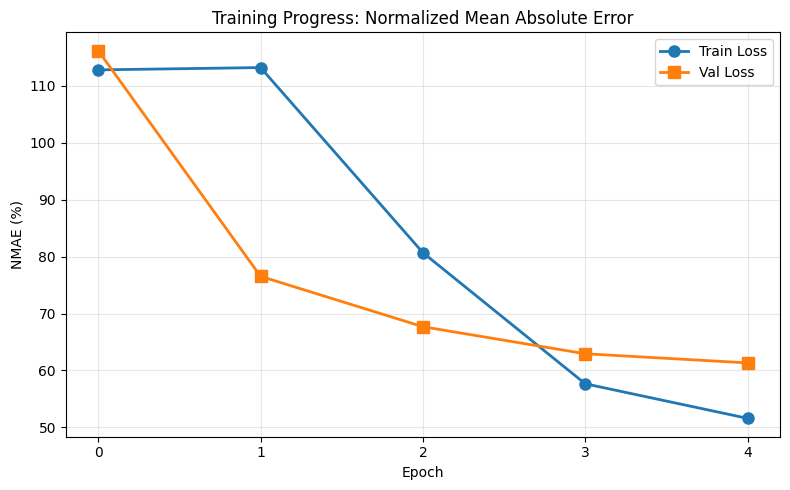

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    df["epoch"],
    df["train_loss_pct"],
    "o-",
    label="Train Loss",
    linewidth=2,
    markersize=8,
)
ax.plot(
    df["epoch"], df["val_loss_pct"], "s-", label="Val Loss", linewidth=2, markersize=8
)
ax.set_xlabel("Epoch")
ax.set_ylabel("NMAE (%)")
ax.set_title("Training Progress: Normalized Mean Absolute Error")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(df["epoch"])
plt.tight_layout()
plt.show()

## 7. Verification

Check that final validation loss matches expected value (determinism test).

In [9]:
final_val_loss = df["val_loss"].iloc[-1]
diff = abs(final_val_loss - EXPECTED_FINAL_VAL_LOSS)

print(f"Final val_loss: {final_val_loss:.6f}")
print(f"Expected:       {EXPECTED_FINAL_VAL_LOSS:.6f}")
print(f"Difference:     {diff:.6f}")
print(f"Tolerance:      {TOLERANCE:.6f}")
print()

if diff <= TOLERANCE:
    print("PASS: Deterministic training verified!")
else:
    raise AssertionError(
        f"FAIL: val_loss {final_val_loss:.6f} differs from expected "
        f"{EXPECTED_FINAL_VAL_LOSS:.6f} by {diff:.6f} (tolerance: {TOLERANCE})"
    )

Final val_loss: 0.639477
Expected:       0.639477
Difference:     0.000000
Tolerance:      0.001000

PASS: Deterministic training verified!
